<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/LR5_Zahynaiko_Pavlo_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота №5

Варіант 8

Загинайко Павло ФІТ 2-17

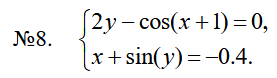

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import optimize

Побудова графіка функції

In [4]:
x_min, x_max = -2, 1
y_min, y_max = -1, 1
step = 0.01

Створюємо масиви значень x та y

In [5]:
x_range = np.arange(x_min, x_max, step)
y_range = np.arange(y_min, y_max, step)
X, Y = np.meshgrid(x_range, y_range)

Рівняння системи для побудови (f(x,y) = 0)

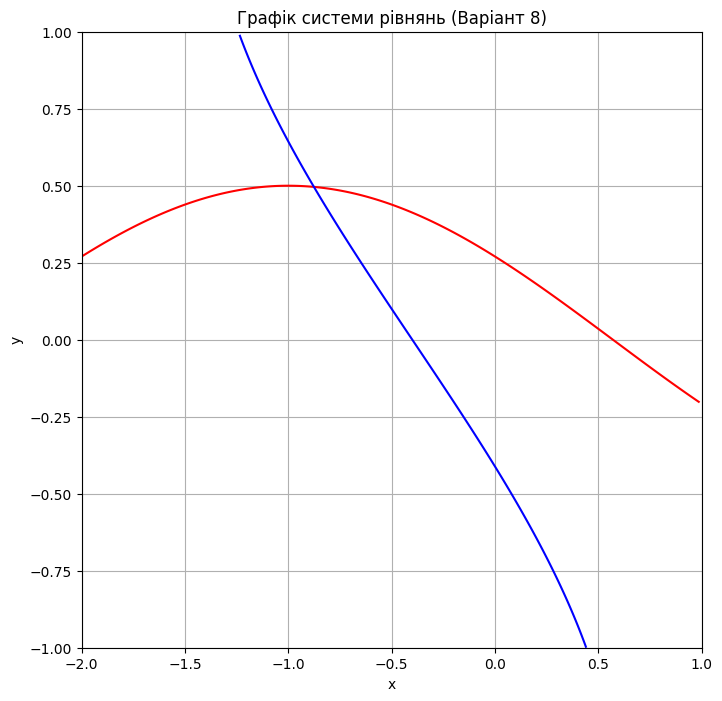

In [6]:
eq1 = 2*Y - np.cos(X + 1)
eq2 = X + np.sin(Y) + 0.4

fig, ax = plt.subplots(figsize=(8, 8))
ax.contour(X, Y, eq1, levels=[0], colors='red')
ax.contour(X, Y, eq2, levels=[0], colors='blue')

ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Графік системи рівнянь (Варіант 8)')
plt.grid(True)
plt.show()


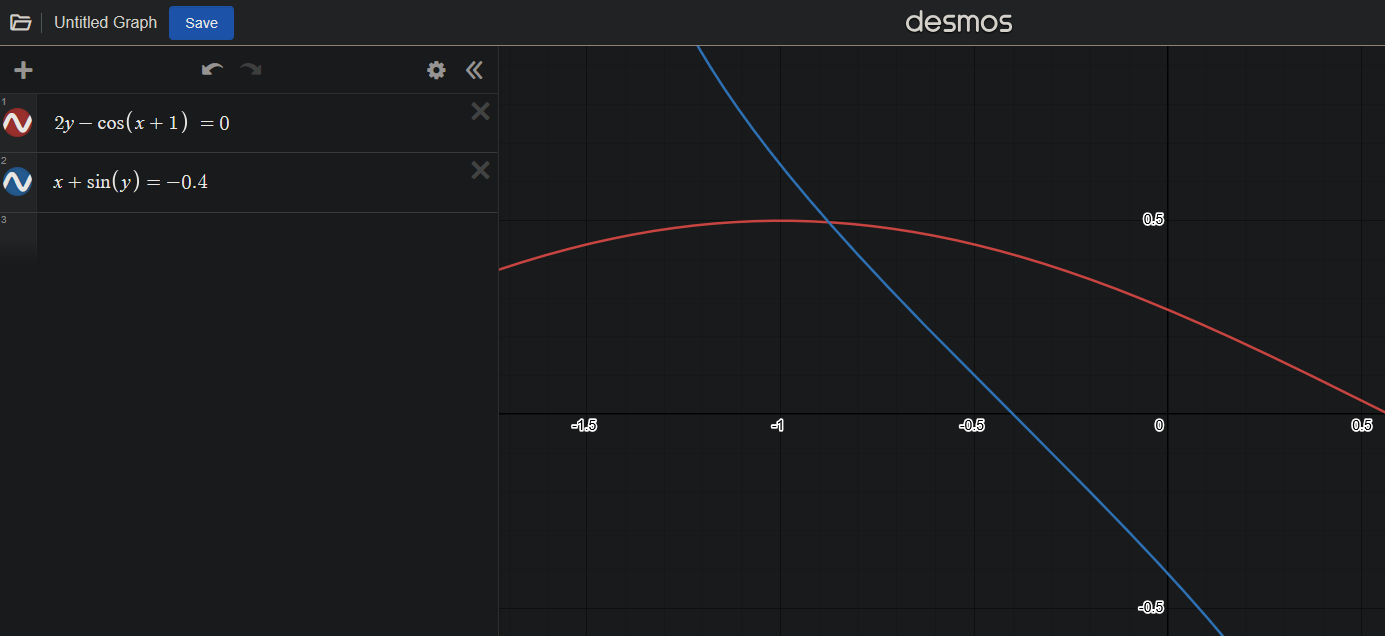

Розв'язок системи рівнянь методом простої ітерації

Початкові наближення (взяті з графіка)

In [7]:
x0 = -0.8
y0 = 0.4

In [8]:
def f1(y):
    return -0.4 - math.sin(y)

def f2(x):
    return 0.5 * math.cos(x + 1)

In [9]:
def iter_method(x_start, y_start, e):
    xn = x_start
    yn = y_start

    # Перша ітерація
    xn1 = f1(yn)
    yn1 = f2(xn)
    n = 1

    while (abs(xn1 - xn) > e) or (abs(yn1 - yn) > e):
        xn = xn1
        yn = yn1
        xn1 = f1(yn)
        yn1 = f2(xn)
        n += 1

    print('Simple iteration:')
    print(f'x = {xn1:.6f}')
    print(f'y = {yn1:.6f}')
    print(f'The amount of iterations = {n}')

# Виклик методу (точність 0.001)
iter_method(x0, y0, 0.001)

Simple iteration:
x = -0.875702
y = 0.496146
The amount of iterations = 5


Перевірка за допомогою scipy.optimize

In [10]:
def f3(vars):
    x_val, y_val = vars
    # Повертаємо вихідні рівняння варіанту 8
    return [2*y_val - math.cos(x_val + 1),
            x_val + math.sin(y_val) + 0.4]

# Використовуємо ті ж початкові наближення
s = optimize.root(f3, [x0, y0], method='hybr')

print('\nCheck (scipy.root):')
print(f'x = {s.x[0]:.6f}')
print(f'y = {s.x[1]:.6f}')


Check (scipy.root):
x = -0.876056
y = 0.496164
